- langchain - pre coded classes for implementing the basic react kind of agent
- langgraph - but if you want to design agent from scratch then use the langgprah.... low level control over the program

In [1]:
def hello_node(input: str):
    return {"message": f"Hello, {input}!"}

In [2]:
hello_node("areeb")

{'message': 'Hello, areeb!'}

In [3]:
from typing_extensions import TypedDict

In [4]:
class State(TypedDict):
    message: str

In [5]:
state: State = {"message": "hello areeb"}
state

{'message': 'hello areeb'}

In [6]:
def hello_node(state: State):
    return {"message": f"Hello, {state['message']}!"}

In [7]:
from langgraph.graph import StateGraph, START, END

In [12]:
builder = StateGraph(State)

In [13]:
builder.add_node("first_hello_node", hello_node)

In [14]:
builder.add_edge(START, "first_hello_node")

In [15]:
builder.add_edge("first_hello_node", END)

In [16]:
graph = builder.compile()

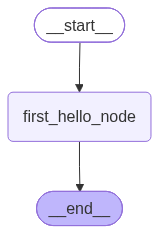

In [18]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [20]:
graph.invoke({"message": "from INDIA"})

{'message': 'Hello, from INDIA!'}

In [21]:
result = graph.invoke({"message": "from INDIA"})

In [22]:
result["message"]

'Hello, from INDIA!'

In [60]:
class Areeb(TypedDict):
    text: str

In [61]:
def function1(state: Areeb):
    print(f"state from first function : {state}")
    return {"text": state["text"] + " from first function"}

In [70]:
def function2(state: Areeb):
    print(f"state from second function : {state}")
    return {"text": state["text"] + " areeb from second function"}

In [71]:
workflow = StateGraph(Areeb)

In [72]:
workflow.add_node("func1", function1)
workflow.add_node("func2", function2)

In [73]:
workflow.add_edge(START, "func1")
workflow.add_edge("func1", "func2")
workflow.add_edge("func2", END)

In [74]:
app = workflow.compile()

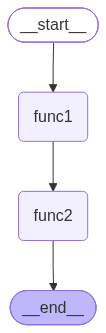

In [75]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [76]:
result = app.invoke({"text": "hi, this is Areeb"})

state from first function : {'text': 'hi, this is Areeb'}
state from second function : {'text': 'hi, this is Areeb from first function'}


In [77]:
result

{'text': 'hi, this is Areeb from first function areeb from second function'}

In [78]:
result["text"]

'hi, this is Areeb from first function areeb from second function'

state from first function before return(this is input to the first function) : {'text': 'hi this is sunny'}
state from second function before return statement(this is output from the first function) : {'text': 'hi this is sunny from first function'}
final state after the section function output: {'text': 'hi this is sunny from first function savita from second function'}

Another workflow

In [79]:
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage

In [80]:
from dotenv import load_dotenv
import os

load_dotenv()

True

In [81]:
if not os.getenv("GROQ_API_KEY"):
    raise ValueError(
        "GROQ_API_KEY not found. Please add it to your .env file."
    )

In [82]:
MODEL_NAME = "openai/gpt-oss-20b"
llm = ChatGroq(
    model=MODEL_NAME,
    temperature=0.6,
    reasoning_format="hidden"
)

In [83]:
response = llm.invoke("Hi")
print(response.content)

Hello! How can I help you today?


In [84]:
from langgraph.graph import MessagesState

In [85]:
def call_model(state: MessagesState):

    print("\n=========================")
    print("MYBOT NODE")
    print("=========================")

    # Get complete conversation history
    messages = state["messages"]

    print("Current Messages:", messages)

    # Send complete message history to LLM
    response = llm.invoke(messages)

    print("\nModel Response:",response.content)

    # MessagesState internally uses add_messages reducer.
    # Therefore the new AIMessage will be added
    # to the existing list of messages.
    return {"messages": [response]}

In [86]:
workflow = StateGraph(MessagesState)

In [87]:
workflow.add_node("mybot", call_model)

In [88]:
workflow.add_edge(START, "mybot")
workflow.add_edge("mybot", END)

In [89]:
app = workflow.compile()

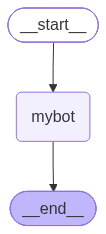

In [90]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [91]:
input = {"messages": [HumanMessage(content="Hi hello, how are you?")]}

In [92]:
result = app.invoke(input)


MYBOT NODE
Current Messages: [HumanMessage(content='Hi hello, how are you?', additional_kwargs={}, response_metadata={}, id='af78cb9f-ae9f-42b3-82c4-44de3334d43d')]

Model Response: Hi there! I’m doing great—thanks for asking. How can I help you today?


State Schema
│
├── TypedDict
│
│   class State(TypedDict):
│       text: str
│
├── Dataclass
│
│   @dataclass
│   class State:
│       text: str
│
├── Pydantic
│
│   class State(BaseModel):
│       text: str
│
└── Built-in MessagesState
    │
    └── messages + add_messages

Another workflow

In [121]:
# example llm call to understand metadata
response =llm.invoke("hi hello how are you?")

In [122]:
response.content

'Hello! I’m doing great—thanks for asking. How can I help you today?'

In [123]:
response.usage_metadata

{'input_tokens': 77,
 'output_tokens': 56,
 'total_tokens': 133,
 'output_token_details': {'reasoning': 29}}

In [107]:
from typing_extensions import TypedDict, NotRequired
from langchain_core.messages import AIMessage
class State(TypedDict):
    # User input
    question: str
    # Generated answer
    answer: NotRequired[str]
    # Complete model response
    response: NotRequired[AIMessage]
    # Token information
    input_tokens: NotRequired[int]
    output_tokens: NotRequired[int]
    total_tokens: NotRequired[int]

In [108]:
def llm_node(state: State):
    print("\n========================")
    print("LLM NODE")
    print("========================")
    
    response = llm.invoke(state["question"])
    print("\nGenerated Answer:\n", response.content)
    
    # IMPORTANT:
    # We are NOT counting tokens here.
    # We simply save the complete AIMessage
    # so the next node can inspect its token metadata.
    return { "answer": response.content, "response": response}


In [109]:
def token_counter(state: State):
    print("\n========================")
    print("TOKEN COUNTER NODE")
    print("========================")
    response = state["response"]
    
    usage = response.usage_metadata or {}

    input_tokens = usage.get("input_tokens")
    output_tokens = usage.get("output_tokens")
    total_tokens = usage.get("total_tokens")

    print("Input Tokens:", input_tokens)
    print("Output Tokens:", output_tokens)
    print("Total Tokens:", total_tokens)

    return {"input_tokens": input_tokens, "output_tokens": output_tokens, "total_tokens": total_tokens}

In [110]:
workflow = StateGraph(State)

In [111]:
workflow.add_node("llm", llm_node)

In [112]:
workflow.add_node("token_counter", token_counter)

In [113]:
workflow.add_edge(START, "llm")
workflow.add_edge("llm", "token_counter")
workflow.add_edge("token_counter", END)

In [114]:
app = workflow.compile()

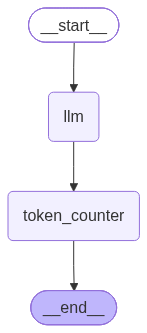

In [115]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [116]:
result = app.invoke({"question": "Tell me about Tata Group in detail."})


LLM NODE

Generated Answer:
 **Tata Group – A Comprehensive Overview**

| Item | Detail |
|------|--------|
| **Founded** | 1868 (as Tata Iron and Steel Company) |
| **Founder** | Jamsetji Tata |
| **Headquarters** | Mumbai, India (Tata Sons Ltd. – the holding company) |
| **Core Values** | “We do the right thing” – ethical, responsible, and sustainable business |
| **Global Presence** | 100+ countries, 100,000+ employees, 10+ sectors |
| **Key Holding** | Tata Sons Ltd. (66 % owned by Tata Trusts) |
| **Chairman (2026)** | Natarajan Chandrasekaran |
| **Revenue (FY 2025)** | ~₹3.6 trn (~US$47 bn) |
| **Market Cap (Tata Sons)** | ~US$35 bn (as of mid‑2026) |

---

## 1. Historical Milestones

| Year | Event |
|------|-------|
| **1868** | Tata Iron and Steel Company (TISCO) founded in Jamshedpur, the first steel plant in India. |
| **1912** | Tata Group starts its first overseas venture – Tata Oil Mills in the UK. |
| **1938** | Tata Motors (then Tata Engineering & Locomotive Co.) beg

In [117]:
result

{'question': 'Tell me about Tata Group in detail.',
 'answer': '**Tata Group – A Comprehensive Overview**\n\n| Item | Detail |\n|------|--------|\n| **Founded** | 1868 (as Tata Iron and Steel Company) |\n| **Founder** | Jamsetji Tata |\n| **Headquarters** | Mumbai, India (Tata Sons Ltd. – the holding company) |\n| **Core Values** | “We do the right thing” – ethical, responsible, and sustainable business |\n| **Global Presence** | 100+ countries, 100,000+ employees, 10+ sectors |\n| **Key Holding** | Tata Sons Ltd. (66\u202f% owned by Tata Trusts) |\n| **Chairman (2026)** | Natarajan\u202fChandrasekaran |\n| **Revenue (FY\u202f2025)** | ~₹3.6\u202ftrn (~US$47\u202fbn) |\n| **Market Cap (Tata Sons)** | ~US$35\u202fbn (as of mid‑2026) |\n\n---\n\n## 1. Historical Milestones\n\n| Year | Event |\n|------|-------|\n| **1868** | Tata Iron and Steel Company (TISCO) founded in Jamshedpur, the first steel plant in India. |\n| **1912** | Tata Group starts its first overseas venture – Tata Oil Mil

Another workflow

In [1]:
import os
import json
from typing import TypedDict, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv
# LangChain
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.document_loaders import (
    TextLoader,
    DirectoryLoader,
)
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_tavily import TavilySearch
# LangGraph
from langgraph.graph import (
    StateGraph,
    START,
    END,
)

C:\Users\ahmad\AppData\Local\Temp\ipykernel_12456\2074771821.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import (


In [2]:
MODEL_NAME = "openai/gpt-oss-20b"
llm = ChatGroq(
    model=MODEL_NAME,
    temperature=0.6,
    reasoning_format="hidden"
)
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.1', 'langchain': '1.3.13'}}, output_version=None, profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000002761C592350>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002761C801150>, model_name='openai/gpt-oss-20b', temperature=0.6, reasoning_format='hidden', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [3]:
embeddings = HuggingFaceEmbeddings(model_name="BAAI/bge-small-en-v1.5")

In [4]:
embedding_vector = embeddings.embed_query("Hello")
print("Embedding Dimension:",len(embedding_vector))

Embedding Dimension: 384


In [5]:
Data_Path = r"D:\Coding\Full-Stack-GenAI-AgenticAI-Bootcamp\06_Agentic_AI\data"

In [6]:
loader = DirectoryLoader(
    Data_Path,
    glob="*.txt",
    loader_cls=TextLoader,
    loader_kwargs={
        "encoding": "utf-8"
    }
)

In [7]:
docs = loader.load()
print("Total documents loaded:", len(docs))

Total documents loaded: 1


In [8]:
docs

[Document(metadata={'source': 'D:\\Coding\\Full-Stack-GenAI-AgenticAI-Bootcamp\\06_Agentic_AI\\data\\sample.txt'}, page_content='The United States economy is one of the largest and most diversified economies in the world. It is driven mainly by services, technology, finance, healthcare, manufacturing, retail, and consumer spending. The country has a strong startup ecosystem and is home to many global companies such as Microsoft, Apple, Amazon, Google, and Tesla. Innovation, research, advanced infrastructure, and access to capital support long-term economic growth. The U.S. dollar is widely used in international trade and is also a major global reserve currency. The country exports aircraft, software, pharmaceuticals, industrial equipment, agricultural goods, and financial services. Major economic challenges include inflation, public debt, income inequality, housing costs, and competition from other global economies. The Federal Reserve manages monetary policy by adjusting interest rate

In [9]:
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=20
)

In [10]:
new_docs = text_splitter.split_documents(docs)
print("Total chunks:", len(new_docs))

Total chunks: 13


In [11]:
new_docs

[Document(metadata={'source': 'D:\\Coding\\Full-Stack-GenAI-AgenticAI-Bootcamp\\06_Agentic_AI\\data\\sample.txt'}, page_content='The United States economy is one of the largest and most diversified economies in the world. It is'),
 Document(metadata={'source': 'D:\\Coding\\Full-Stack-GenAI-AgenticAI-Bootcamp\\06_Agentic_AI\\data\\sample.txt'}, page_content='in the world. It is driven mainly by services, technology, finance, healthcare, manufacturing,'),
 Document(metadata={'source': 'D:\\Coding\\Full-Stack-GenAI-AgenticAI-Bootcamp\\06_Agentic_AI\\data\\sample.txt'}, page_content='manufacturing, retail, and consumer spending. The country has a strong startup ecosystem and is'),
 Document(metadata={'source': 'D:\\Coding\\Full-Stack-GenAI-AgenticAI-Bootcamp\\06_Agentic_AI\\data\\sample.txt'}, page_content='ecosystem and is home to many global companies such as Microsoft, Apple, Amazon, Google, and Tesla.'),
 Document(metadata={'source': 'D:\\Coding\\Full-Stack-GenAI-AgenticAI-Bootcamp\\06

In [12]:
vector_store = Chroma(
    collection_name="usa_economy",
    embedding_function=embeddings
)

In [13]:
vector_store.add_documents(
    documents=new_docs
)

['5ccacc98-ebbe-4a4a-a297-9362875286ac',
 '55541333-53be-40c7-b95f-66ef3896f226',
 '6025d24f-7539-4277-bd58-74bf478d48db',
 '14aff40a-66b2-417d-9d18-c01ad0f29cdc',
 'e82b798b-8e2f-48dd-8a93-8f1febf56bbc',
 '5d72b71c-a6cb-41aa-a9a1-f2a55b8ce15a',
 '053905bf-707f-4921-b0be-c990312114d3',
 '707b6f64-2261-446e-a66b-646d63154880',
 'c6bf7071-ce74-494c-b888-dfcba761e4d7',
 '4844b736-adb7-4b01-b67f-d731c4d7ee28',
 '24aa292b-7b83-47a2-bcbe-a9f126cdfd0b',
 'f25a6ad1-0c11-4a9e-9a8c-43dae3566ad8',
 'ed1e1d38-682d-4a71-9670-c2e5f5d180f0']

In [14]:
retriever = vector_store.as_retriever(
    search_kwargs={
        "k": 3
    }
)

In [15]:
test_documents = retriever.invoke("What is GDP of USA?")

for document in test_documents:
    print(document.page_content)
    print("-" * 50)

The United States economy is one of the largest and most diversified economies in the world. It is
--------------------------------------------------
economies. The Federal Reserve manages monetary policy by adjusting interest rates and controlling
--------------------------------------------------
goods, and financial services. Major economic challenges include inflation, public debt, income
--------------------------------------------------


In [16]:
from langchain_tavily import TavilySearch

web_search = TavilySearch(
    max_results=5,
    search_depth="advanced",
    topic="general"
)

In [17]:
result = web_search.invoke({"query": "What is the latest AI news?"})

In [18]:
print(result)

{'query': 'What is the latest AI news?', 'follow_up_questions': None, 'answer': None, 'images': [], 'results': [{'url': 'https://blog.google/innovation-and-ai/technology/ai/google-ai-updates-july-2026', 'title': 'The latest AI news we announced in July 2026 - Google Blog', 'content': '# The latest AI news we announced in July 2026\n\nAug 04, 2026\n\n|\n9 min read\n\n   x.com\n   Facebook\n   LinkedIn\n   Mail\n   Copy link \n\nHere’s a recap of some of our biggest AI updates from July, including three new Gemini models for building AI agents at scale and Gemini Robotics ER 2 to help robots reason, collaborate, and solve real-world tasks.\n\n  \n\nNews from Google Team\n\n Share \n\n   x.com\n   Facebook\n   LinkedIn\n   Mail\n   Copy link \n\n  \n\nImage 2: July AI recap header\n\n00:00\n\nAudio 1\n\n Listen to article \n\n minutes\n\nThis content is generated by Google AI. Generative AI is experimental\n\nVoice Umbriel Speed 1X\n\nVoice Umbriel Gacrux\n\nSpeed 0.75X 1X 1.5X 2X\n\n Rea